In this notebook, I'll be going over some common image editor functions, and some advanced ones, to cover the basics of image processing. Over the course of this series, we'll be building a full-feature editor, like the one you may find on your phone.

Roadmap:
1. Basic Color Editing (you are here)
2. Advanced Color Editing
3. Convolutional Operations and Segmentation

### Part 1: Basic Color Editing

In this article, we will cover basic color editing features present in most photo editing apps.

In [4]:
import numpy as np
from matplotlib import pyplot as plt

from PIL.Image import open

### Setup and the Image Histogram

The below methods provide some code for convenience throughout the notebook. In particular, the `plot_image_histogram` method is useful for seeing how our transformations numerically affects the characteristics of the image.

The `convert_to_32bit` decorator will be used in many of the functions below. This decorator, in line with pro photo editors, converts RGB values from 8-bit ints to 32-bit floats between 0 and 1 (and back), which helps us write more precise transformations.

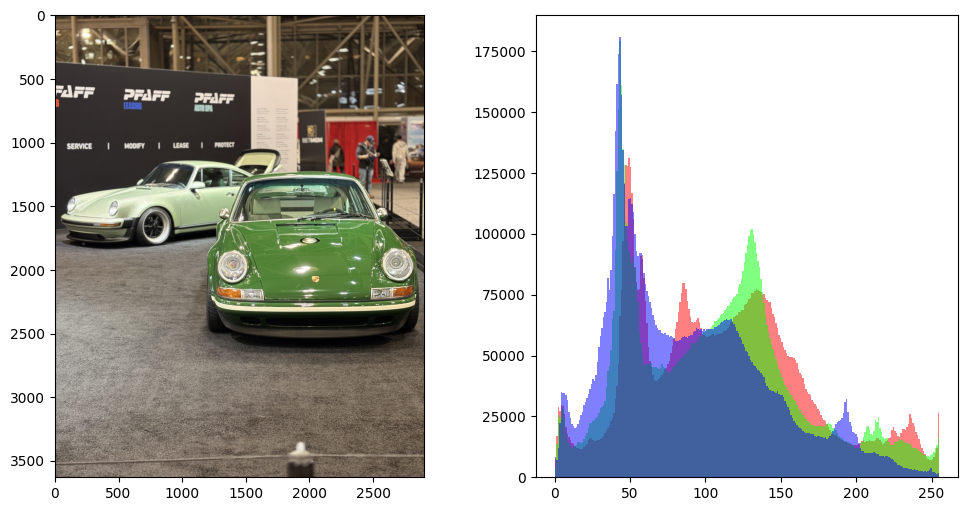

In [114]:
def convert_to_32bit(func):
    def impl(*args, **kwargs):
        img = np.array(args[0] / 255, dtype=np.float32)
        return np.array(np.clip(func(img, *args[1:], **kwargs) * 255, 0, 255), dtype=np.uint8)
    return impl

def plot_image(img, ax):
    ax.imshow(img)

def plot_image_histogram(img, ax):
    r = img[:, :, 0].reshape(-1)
    g = img[:, :, 1].reshape(-1)
    b = img[:, :, 2].reshape(-1)
    ax.hist(r, 256, color="#ff00007f")
    ax.hist(g, 256, color="#00ff007f")
    ax.hist(b, 256, color="#0000ff7f")

def plot_image_data(img):
    f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    plot_image(img, ax1)
    plot_image_histogram(img, ax2)
    plt.show()

img = np.array(open("image.jpg"))

plot_image_data(img)

### Brightness

To adjust brightness, we add or remove a constant amount from all the channels in the image.

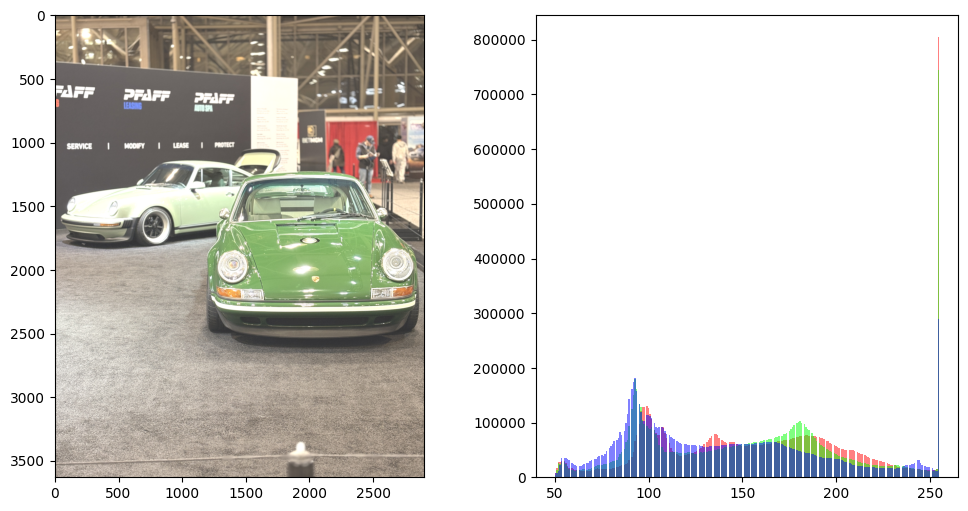

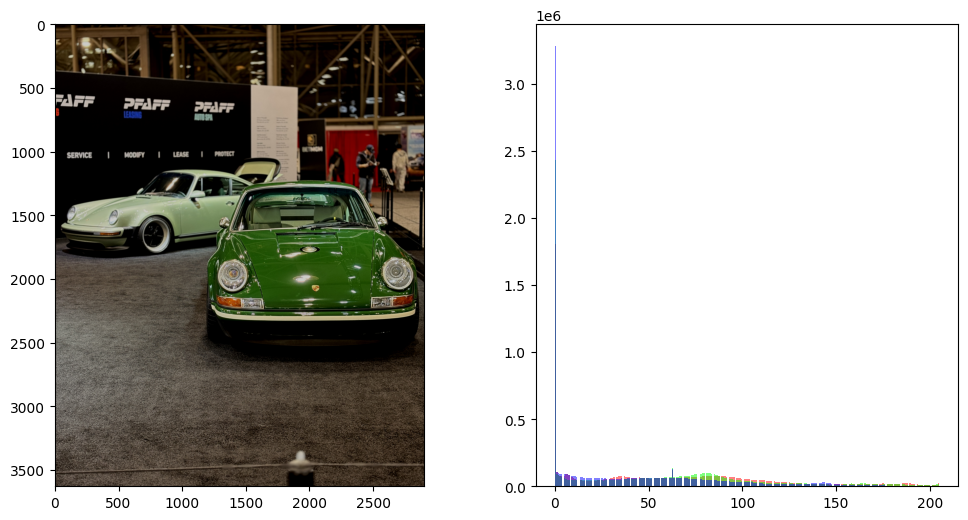

In [115]:
BRIGHTNESS_CONSTANT = 1

@convert_to_32bit
def adjust_brightness(img: np.ndarray, amt: int) -> np.ndarray:
    delta = amt * BRIGHTNESS_CONSTANT / 255
    return img + delta

up_brightness = adjust_brightness(img, 50)
plot_image_data(up_brightness)

down_brightness = adjust_brightness(img, -50)
plot_image_data(down_brightness)

### Contrast

For contrast, we adjust the image around a "midpoint" in our color scale, using a contrast factor. This has the effect of moving colors towards their extremes (towards 0 or 255) if the contrast factor is greater than 1 or towards the midpoint if the contrast factor is below 1.

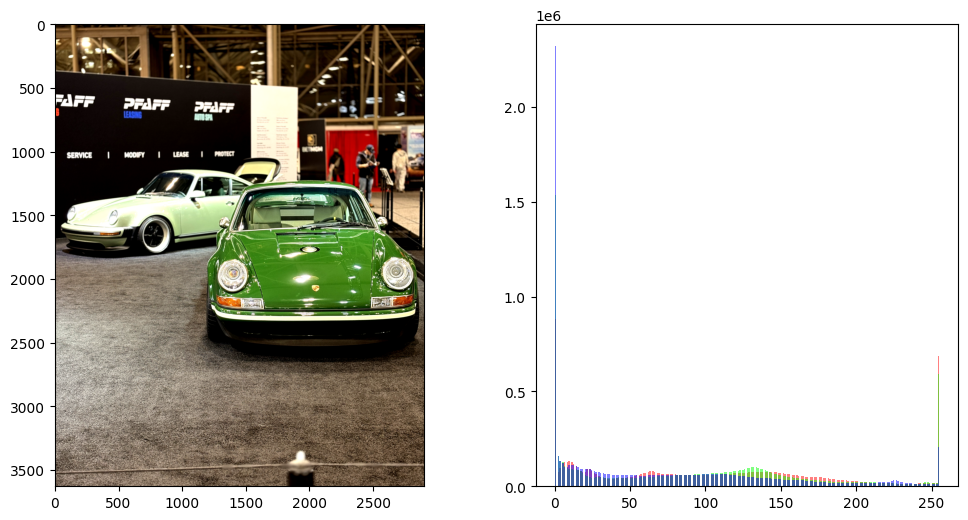

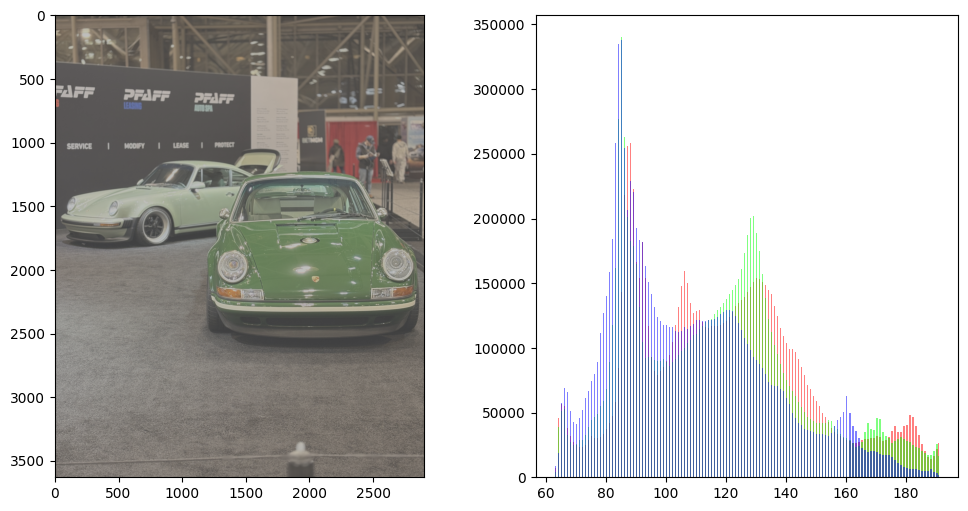

In [116]:
CONTRAST_MIDPOINT = 0.5

@convert_to_32bit
def adjust_contrast(img: np.ndarray, contrast_factor: float) -> np.ndarray:
    return (img - CONTRAST_MIDPOINT) * contrast_factor + CONTRAST_MIDPOINT

high_contrast = adjust_contrast(img, 1.5)
plot_image_data(high_contrast)

low_contrast = adjust_contrast(img, 0.5)
plot_image_data(low_contrast)

### Temperature

Temperature adjusts the image along the blue-yellow axis, to make it look cooler (shot under bluer light) or warmer (shot under yellower light).

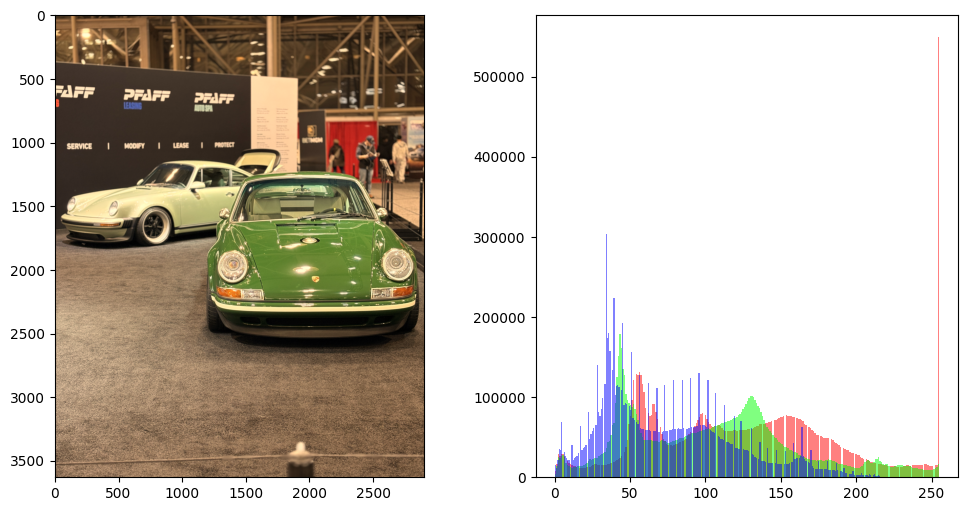

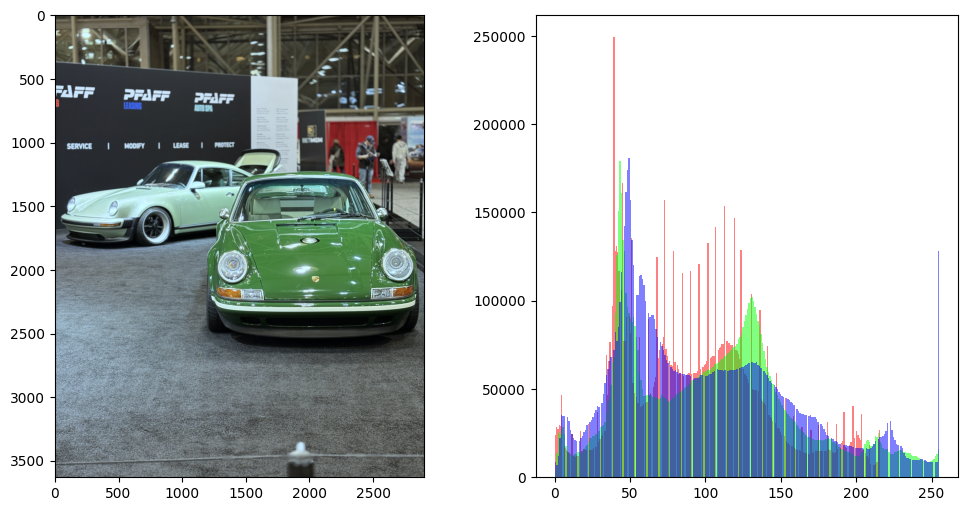

In [165]:
@convert_to_32bit
def adjust_temperature(img, amt):
    r = img[:, :, 0]
    g = img[:, :, 1]
    b = img[:, :, 2]

    red_scale = 1 + amt * 0.5
    blue_scale = 1 - amt * 0.5

    return np.concatenate([
        (r * red_scale).reshape(*img.shape[:-1], 1),
        g.reshape(*img.shape[:-1], 1),
        (b * blue_scale).reshape(*img.shape[:-1], 1),
    ], axis=2)

temperature_up = adjust_temperature(img, 0.3)
plot_image_data(temperature_up)

temperature_down = adjust_temperature(img, -0.3)
plot_image_data(temperature_down)

### Tint

Tint adjusts the image along the green-magenta axis, giving the impression of being shot under weaker fluorescent light (magenta shift) or stronger fluorescent light (green shift).

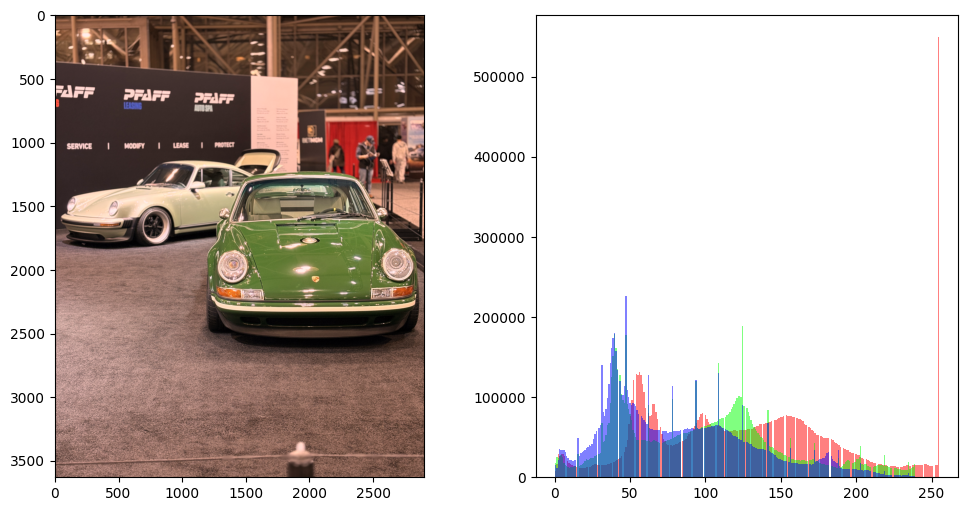

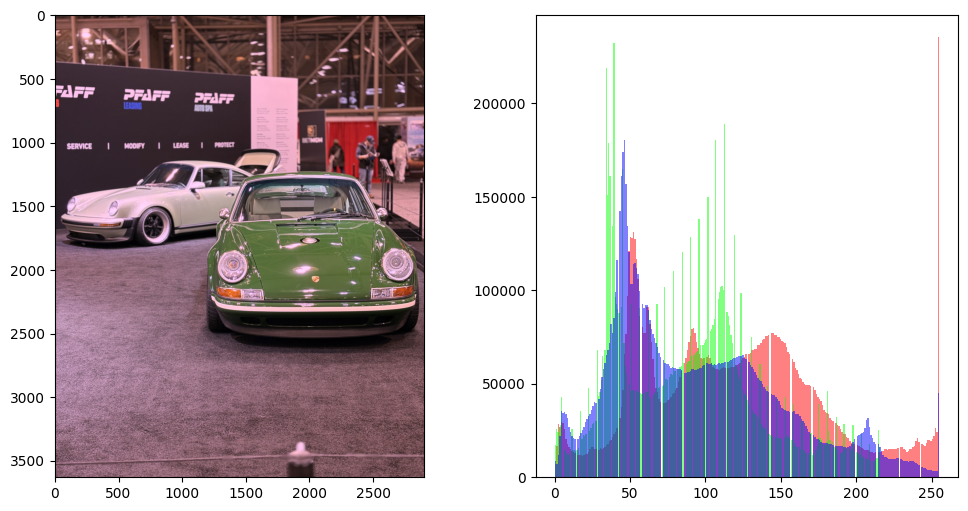

In [166]:
@convert_to_32bit
def adjust_tint(img, amt):
    r = img[:, :, 0]
    g = img[:, :, 1]
    b = img[:, :, 2]

    if amt > 0:
        red_scale = 1 + amt * 0.5
        green_scale = 1 - amt * 0.2
        blue_scale = 1 - amt * 0.2
    else:
        red_scale = 1 - amt * 0.25
        green_scale = 1 + amt * 0.5
        blue_scale = 1 - amt * 0.25

    return np.concatenate([
        (r * red_scale).reshape(*img.shape[:-1], 1),
        (g * green_scale).reshape(*img.shape[:-1], 1),
        (b * blue_scale).reshape(*img.shape[:-1], 1),
    ], axis=2)

tint_up = adjust_tint(img, 0.3)
plot_image_data(tint_up)

tint_down = adjust_tint(img, -0.3)
plot_image_data(tint_down)

### HSL conversion and Specific Color Editing

#### Overview

Specific colors cannot be edited in RGB space. Instead, we translate the image to HSL. HSL lets you control the color as a single value (H: [0, 359]), along with its saturation (S: [0, 1]) and lightness (L: [0, 1]). Note that the ranges on H, S and L are arbitrary and can vary depending on the software you are using. Note as well that there are many variants of this system (HSV, HLS, HSI) but they are, for our purposes, effectively the same.

RGB has a couple of problems which are not immediately apparent:
- it allows a certain amount of colors, but this isn't every single possible color. The selection of colors offered by RGB is called its gamut, and there are other color systems with much larger gamuts.
- moving from one color to another is not intuitive in RGB- you can't simply adjust one slider and expect the color to move in the direction you want it to (e.g. adding more red to make an orange color lighter does not typically work).
- additive/subtractive models such as RGB do not mimic human perception.
- it's difficult to pick out a specific range of colors in RGB. For example, if you wanted to edit all the reds in a photo, well, every color in the photo likely has some amount of red. Thus the thresholds would be very difficult to determine convincingly.

HSL solves these problems (though it's not perfect):
- it has a larger gamut than RGB (usually not needed).
- you only adjust 1 value (H) to move between colors.
- it does a better job of mimicking human eprception, given that we typically see colors as 1) what they are, 2) how full/dull then are, and 3) how dark/light they are.
- a specific color range in HSL is the hue +/- a set amount (wrapping around at 360 degrees).

This makes object identification and color grading much easier, both manually and programmatically.

#### But what exactly is HSL?

Hue is a single value meant to represent the color you are seeing, as a broad category (think how we rarely describe colors past "red", "green", "blue"). To define hue mathematically, we can think of RGB as a cube with 2 dimensions: R, G, and B of course. At (0, 0, 0) we have black, and at (255, 255, 255) we have white. There are 3 vertices for red (255, 0, 0), green (0, 255, 0) and blue (0, 0, 255), and 3 more for yellow (255, 255, 0), cyan (0, 255, 255), and magenta (255, 0, 255). We can flip this cube such that it rests on the black vertex, and the resulting projection would be hexagonal (see the [following diagram](https://upload.wikimedia.org/wikipedia/commons/thumb/5/52/HSL-HSV_hue_and_chroma.svg/960px-HSL-HSV_hue_and_chroma.svg.png), the explanation is difficult to make sense of without it). Now, consider a color in this space. It would be a vector within the cube. We can get its projection onto the hexagon. The angle within the hexagon (assuming red falls at 0 degrees) is the hue. The length of the projection is the chroma, or the largest channel of the color minus the smallest channel. Chroma can be defined as how colorful a region is relative to a grey of the same lightness. The mathematical definition holds here, think of how the chroma would be large for a bright color like full red (255, 0, 0) but small for middle grey (128, 128, 128).

Lightness is simply the average of the largest and smallest channels of the image. This is the "mid-range" of the color.

Saturation is simply chroma scaled by the maximum possible chroma for the current value of lightness. The maximum possible chroma is simply the largest channel (r, g, or b). We can then remove the lightness from it via subtraction, then divide by the lightness. We use the lower of `L` and `1 - L` to account for whether you are in the dark half or light half of the lightness range. Why does this matter? As you decrease the lightness from 0.5, the "fullness" of a can only be so much (think of how a darker red would be less full than a normal, bright red). Similarly, as you increase the lightness from 0.5, the "fullness" of a can only be so much (think of how a light, washed-out red would be less full than a normal, bright red). Thus, the fullness of your color is limited by your lightness regardless of how much it is. Thus, we should reflect that by using the lower value of `L` and `1 - L` to be a better measure of fullness, or saturation!

/var/folders/jp/1s5vzy_x60b136_q90cfy_1c0000gn/T/ipykernel_58026/1327998994.py:16: RuntimeWarning: invalid value encountered in divide
  max_channel_idx == 0, 60 * ((g - b) / rgb_range % 6), 0
/var/folders/jp/1s5vzy_x60b136_q90cfy_1c0000gn/T/ipykernel_58026/1327998994.py:18: RuntimeWarning: invalid value encountered in divide
  max_channel_idx == 1, 60 * ((b - r) / rgb_range + 2), 0
/var/folders/jp/1s5vzy_x60b136_q90cfy_1c0000gn/T/ipykernel_58026/1327998994.py:20: RuntimeWarning: invalid value encountered in divide
  max_channel_idx == 2, 60 * ((r - g) / rgb_range + 4), 0
/var/folders/jp/1s5vzy_x60b136_q90cfy_1c0000gn/T/ipykernel_58026/1327998994.py:28: RuntimeWarning: invalid value encountered in divide
  return np.where(mask, 0, (max_channel - luminance) / np.minimum(luminance, 1 - luminance))


True True True


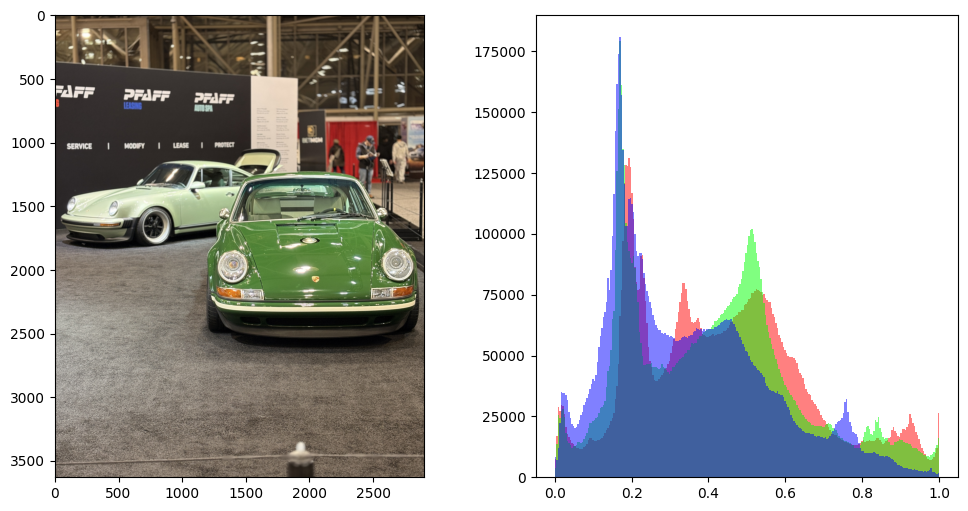

In [ ]:
def rgb_convert_to_hsl(img):
    def calculate_hue(x):
        max_channel = np.max(x, axis=2)
        min_channel = np.min(x, axis=2)
        max_channel_idx = np.argmax(x, axis=2)
        rgb_range = max_channel - min_channel

        r = x[:, :, 0]
        g = x[:, :, 1]
        b = x[:, :, 2]

        return np.where(
            rgb_range == 0, 
            0, 
            np.where(
                max_channel_idx == 0, 60 * ((g - b) / rgb_range % 6), 0
            ) + np.where(
                max_channel_idx == 1, 60 * ((b - r) / rgb_range + 2), 0
            ) + np.where(
                max_channel_idx == 2, 60 * ((r - g) / rgb_range + 4), 0
            )
        )
    
    def calculate_saturation(x):
        lightness = calculate_lightness(x)
        max_channel = np.max(x, axis=2)
        mask = (lightness == 0) | (lightness == 1)
        return np.where(mask, 0, (max_channel - lightness) / np.minimum(lightness, 1 - lightness))

    def calculate_lightness(x):
        max_channel = np.max(x, axis=2)
        min_channel = np.min(x, axis=2)
        return 0.5 * (max_channel + min_channel)
    
    return np.concatenate([
        calculate_hue(np.array(img / 255, dtype=np.float32)).reshape(*img.shape[:-1], 1),
        calculate_saturation(np.array(img / 255, dtype=np.float32)).reshape(*img.shape[:-1], 1),
        calculate_lightness(np.array(img / 255, dtype=np.float32)).reshape(*img.shape[:-1], 1)
    ], axis=2)

hsl_img = rgb_convert_to_hsl(img)

# test against a known implementation
import colorsys

res = np.apply_along_axis(lambda x: colorsys.rgb_to_hls(*x), 2, img / 255)
res[:, :, 0] *= 360

print(
    np.allclose(res[:, :, 0], hsl_img[:, :, 0]),
    np.allclose(res[:, :, 2], hsl_img[:, :, 1]),
    np.allclose(res[:, :, 1], hsl_img[:, :, 2]),
)

hsl_img[:, :, 0] /= 360
reconverted_img = np.apply_along_axis(lambda x: colorsys.hls_to_rgb(*x), 2, hsl_img[:, :, [0, 2, 1]])

plot_image_data(reconverted_img)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


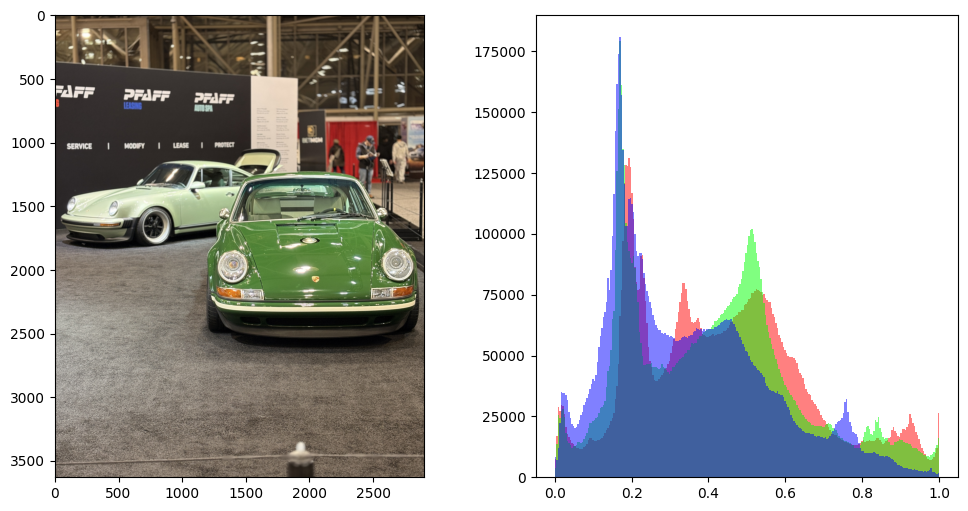

In [ ]:
def hsl_convert_to_rgb(img):
    h = img[:, :, 0]
    s = img[:, :, 1]
    l = img[:, :, 2]

    c = (1 - np.abs(2 * l - 1)) * s
    hp = h / 60
    x = c * (1 - np.abs(hp % 2 - 1))
    r = (
        np.where(
            ((hp >= 0) & (hp < 1)) | ((hp >= 5) & (hp < 6)), 
            c, 
            np.where(
                ((hp >= 1) & (hp < 2)) | ((hp >= 4) & (hp < 5)),  
                x, 
                np.where(
                    ((hp >= 2) & (hp < 3)) | ((hp >= 3) & (hp < 4)),  
                    0, 
                    0
                )
            )
        ) + (l - c / 2)
        
    ).reshape(*img.shape[:-1], 1)
    g = (
        np.where(
            (hp >= 1) & (hp < 3), 
            c, 
            np.where(
                ((hp >= 0) & (hp < 1)) | ((hp >= 3) & (hp < 4)),  
                x, 
                np.where(hp >= 4, 0, 0)
            )
        ) + (l - c / 2)

    ).reshape(*img.shape[:-1], 1)
    b = (
        np.where(
            (hp >= 3) & (hp < 5), 
            c, 
            np.where(
                ((hp >= 2) & (hp < 3)) | ((hp >= 5) & (hp < 6)),  
                x, 
                np.where(hp < 2, 0, 0)
            )
        ) + (l - c / 2)
    ).reshape(*img.shape[:-1], 1)
    
    return np.concatenate([r, g, b], axis=2)

hsl_img[:, :, 0] *= 360
x = hsl_convert_to_rgb(hsl_img)
plot_image_data(x)

### Color Changes Using Hues

Now that we understand HSL, we can use it to perform more advanced edits in our image, like changing certain colors to others. This is done by selecting the hue we are looking to change, and then adjusting the hue, saturation, and lightness of the pixels that fall within that color. We define a "weight" for each pixel in the image, depending on its hue. Hues closer to the target hue are weighed much higher than hues further away, using a Gaussian weight function so that the weighing doesn't have any abrupt transitions. We also avoid changing any colors with low saturation or lightness (or high lightness, which likely indicates white), which are most likely neutral, using a saturation and lightness threshold.

In [140]:
def convert_to_hsl(func):
    def impl(*args, **kwargs):
        img = rgb_convert_to_hsl(args[0])
        return np.array(np.round(np.clip(hsl_convert_to_rgb(func(img, *args[1:], **kwargs)) * 255, 0, 255)), dtype=np.uint8) 
    return impl

/var/folders/jp/1s5vzy_x60b136_q90cfy_1c0000gn/T/ipykernel_58026/1327998994.py:16: RuntimeWarning: invalid value encountered in divide
  max_channel_idx == 0, 60 * ((g - b) / rgb_range % 6), 0
/var/folders/jp/1s5vzy_x60b136_q90cfy_1c0000gn/T/ipykernel_58026/1327998994.py:18: RuntimeWarning: invalid value encountered in divide
  max_channel_idx == 1, 60 * ((b - r) / rgb_range + 2), 0
/var/folders/jp/1s5vzy_x60b136_q90cfy_1c0000gn/T/ipykernel_58026/1327998994.py:20: RuntimeWarning: invalid value encountered in divide
  max_channel_idx == 2, 60 * ((r - g) / rgb_range + 4), 0
/var/folders/jp/1s5vzy_x60b136_q90cfy_1c0000gn/T/ipykernel_58026/1327998994.py:28: RuntimeWarning: invalid value encountered in divide
  return np.where(mask, 0, (max_channel - luminance) / np.minimum(luminance, 1 - luminance))


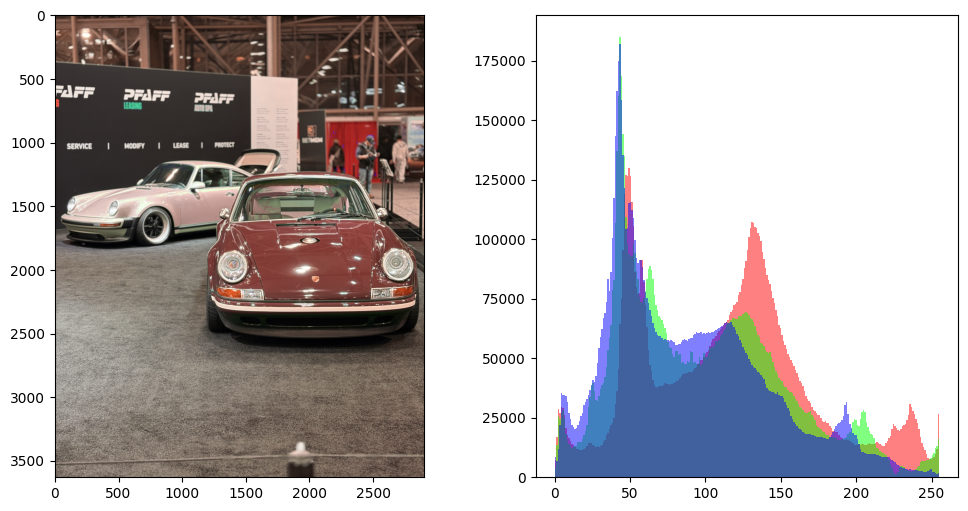

In [ ]:
@convert_to_hsl
def adjust_color(
    img: np.ndarray, 
    old_h: float, 
    new_h: float = None, 
    new_s: float = None, 
    new_l: float = None,
    saturation_threshold: float = 0.15,
    lightness_threshold_bottom: float = 0.1,
    lightness_threshold_top: float = 0.9,
    color_spread: int = 50
):
    h = img[:, :, 0]
    s = img[:, :, 1]
    l = img[:, :, 2]
    distance_from_old_h = np.minimum(np.abs(h - old_h), 360 - np.abs(h - old_h))
    adjustment_amount_h = new_h - h
    adjustment_amount_s = (new_s if new_s is not None else s) - s
    adjustment_amount_l = (new_l if new_l is not None else l) - l
    saturation_gate = np.where(s > saturation_threshold, 1, 0)
    lightness_gate = np.where((l > lightness_threshold_bottom) & (l < lightness_threshold_top), 1, 0)
    falloff = np.exp(-(distance_from_old_h ** 2) / (2 * color_spread ** 2)) * saturation_gate * lightness_gate

    return np.concatenate([
        (h + falloff * adjustment_amount_h).reshape(*img.shape[:-1], 1), 
        (s + falloff * adjustment_amount_s).reshape(*img.shape[:-1], 1), 
        (l + falloff * adjustment_amount_l).reshape(*img.shape[:-1], 1)
    ], axis=2)

plot_image_data(adjust_color(img, 120, 0, color_spread=70))

### Gamma Space

It's intuitive to think of light linearly: if a pixel is twice as bright as another, their intensity values should be 2:1. However, middle grey (128, 128, 128) is not true middle grey to human eyes, despite being right in the middle of a linear scale like RGB. It's actually brighter. To correct for this, computer screens (including yours!) use gamma encoding to correct color. 

We use the sRGB standard to Gamma-encode colors. The formula is simple:

$$c_{sRGB} = c_{RGB}^{(\frac{1}{2.2})}$$

Your image files, including the one in this article, are saved with gamma-encoded values. Your computer screen applies the inverse translation, to a linear scale, before rendering on your screen.

The editing we do in this file has (so far) been in gamma space, given that `matplotlib` loads images from their gamma-encoded files without applying any translation. However, some editing needs to be done in linear scale for more realistic results.

In [101]:
def convert_to_32bit_linear(func):
    def impl(*args, **kwargs):
        img = np.array((args[0] / 255) ** 2.2, dtype=np.float32)
        return np.array(np.clip(func(img, *args[1:], **kwargs) ** (1 / 2.2) * 255, 0, 255), dtype=np.uint8)
    return impl

### Exposure

Exposure editing is meant to simulate taking the photo in higher/lower-light conditions. Exposure is measured in F-stops, which is effectively the amount of time the camera's sensor is exposed to light.

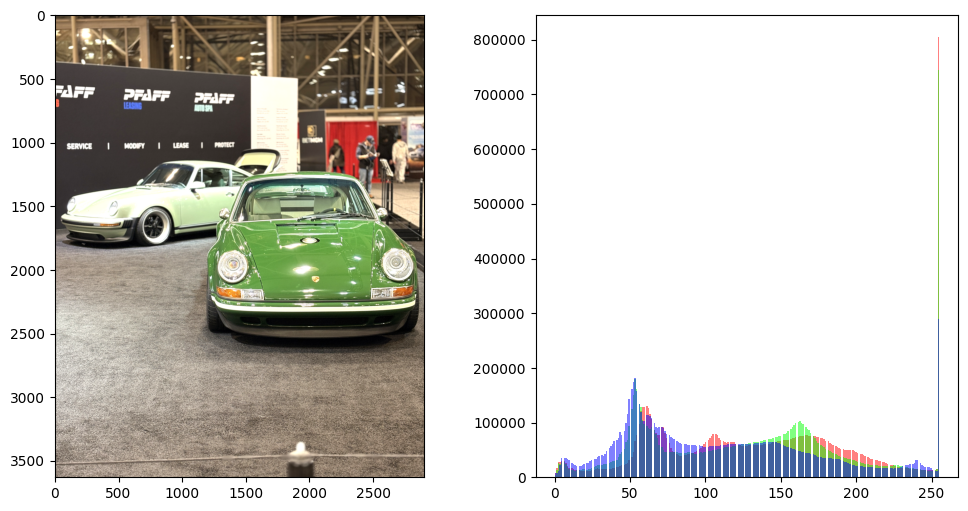

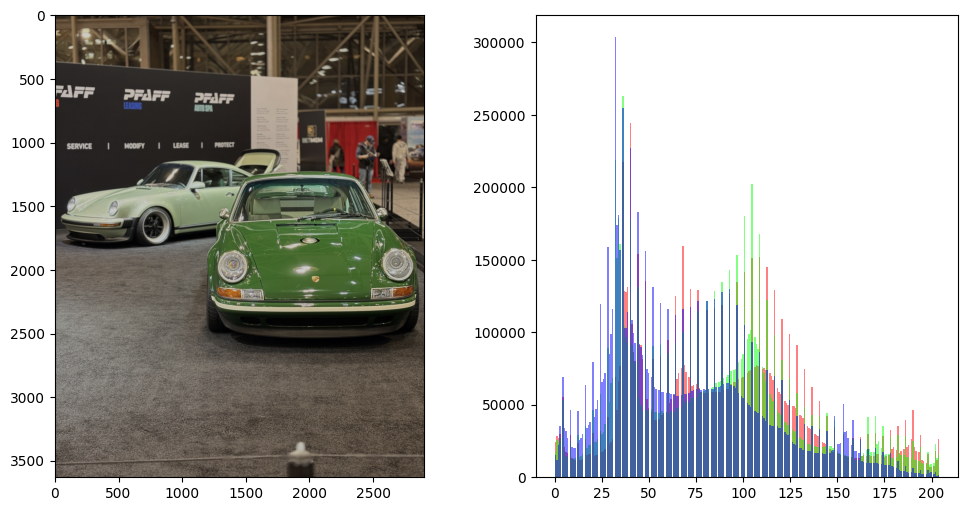

In [134]:
@convert_to_32bit_linear
def adjust_exposure(img: np.ndarray, amt: float) -> np.ndarray:
    return img * 2 ** amt

high_exposure = adjust_exposure(img, 0.7)
plot_image_data(high_exposure)

low_exposure = adjust_exposure(img, -0.7)
plot_image_data(low_exposure)

### Black point

Black point is a simple form of color grading where you change the value that corresponds to pure black. This has the effect of making your shadows more (or less) apparent.

/var/folders/jp/1s5vzy_x60b136_q90cfy_1c0000gn/T/ipykernel_58026/873358639.py:4: RuntimeWarning: invalid value encountered in power
  return np.array(np.clip(func(img, *args[1:], **kwargs) ** (1 / 2.2) * 255, 0, 255), dtype=np.uint8)
/var/folders/jp/1s5vzy_x60b136_q90cfy_1c0000gn/T/ipykernel_58026/873358639.py:4: RuntimeWarning: invalid value encountered in cast
  return np.array(np.clip(func(img, *args[1:], **kwargs) ** (1 / 2.2) * 255, 0, 255), dtype=np.uint8)


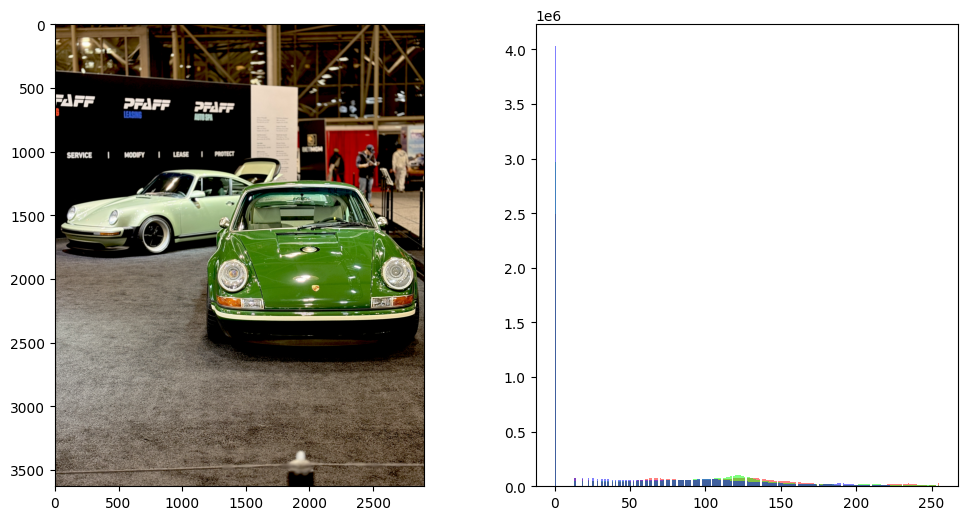

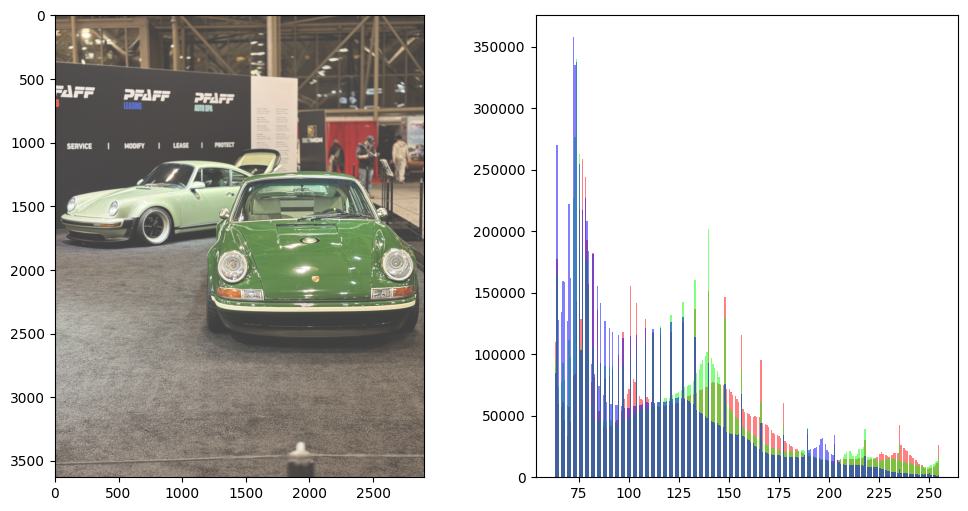

In [135]:
@convert_to_32bit_linear
def adjust_black_point(img: np.ndarray, amt: float) -> np.ndarray:
    return (img - amt) / (1 - amt)

high_black_point = adjust_black_point(img, 0.04)
plot_image_data(high_black_point)

low_black_point = adjust_black_point(img, -0.05)
plot_image_data(low_black_point)

### Using What We Learned

The settings in this article are relatively simple. The key here is to play around with them, and not to overdo it (which is opretty obvious in most cases). To know if you did overdo it, look for loss of colors or extremely light/dark areas.

### Looking ahead

In the next article, we'll be covering more advanced linear transformations, such as professional color grading and blending, plus some editing that takes real skill. Stay tuned!